In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import xgboost 
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, 
)



In [2]:

df = pd.read_csv('Copia de data_merged.csv')



In [3]:

df_processed = df.copy()

initial_rows = len(df_processed)
df_processed = df_processed.dropna()

df_processed['duration_ms'] = df_processed['duration_ms']/60000

def categorize_popularity(popularity):
    if popularity == 0:
        return 0 #no popular
    elif popularity<=20:
        return 1 # baja
    elif popularity <=40:
        return 2 # media
    return 3 # alta

df_processed['popularity_multiclass'] = df_processed['popularity'].apply(categorize_popularity)
print("\nVariable multiclase 3 niveles (popularity_multiclass):")
multiclass_counts = df_processed['popularity_multiclass'].value_counts().sort_index()
multiclass_labels = ['no popular','Baja', 'Media', 'Alta']
for i, (count, label) in enumerate(zip(multiclass_counts, multiclass_labels)):
    print(f"   {i} ({label}): {count} ({count/len(df_processed)*100:.1f}%)")




Variable multiclase 3 niveles (popularity_multiclass):
   0 (no popular): 39729 (23.1%)
   1 (Baja): 34033 (19.8%)
   2 (Media): 51035 (29.6%)
   3 (Alta): 47433 (27.5%)


<Axes: xlabel='popularity_multiclass'>

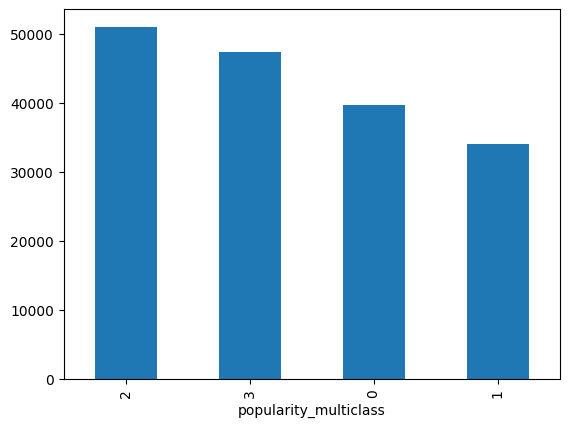

In [4]:
df_processed['popularity_multiclass'].value_counts().plot(kind='bar')

In [5]:


_X = df_processed.copy()

X = _X.drop(columns=['popularity','popularity_multiclass'])
y_multiclass_3 = df_processed['popularity_multiclass'] 



In [6]:
df_processed.groupby('popularity_multiclass')['popularity'].describe()

,count,mean,std,min,25%,50%,75%,max
popularity_multiclass,,,,,,,,
0,39729.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,34033.0,9.619575,6.125172,1.0,4.0,9.0,15.0,20.0
2,51035.0,30.747330,5.652618,21.0,26.0,31.0,36.0,40.0
3,47433.0,54.153163,9.966513,41.0,46.0,52.0,61.0,100.0


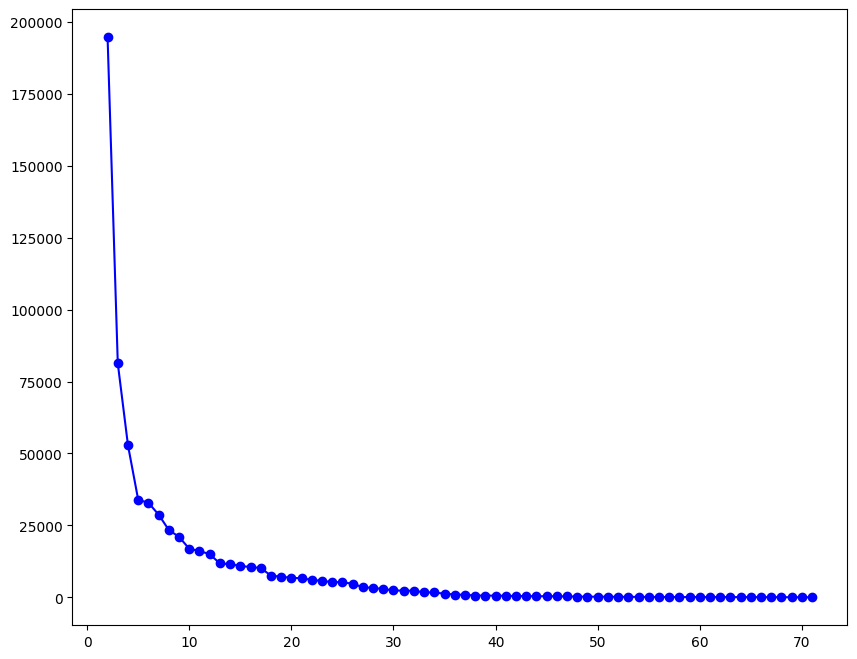

In [7]:

selector = SelectKBest(score_func=f_classif,k='all')
X_new = selector.fit_transform(X,y_multiclass_3)
total_score = selector.scores_
sorted_scoress = np.sort(total_score)[::-1]
plt.figure(figsize=(10,8))
plt.plot(range(1,X.shape[1]+1),sorted_scoress,'bo-')


In [8]:
selector = SelectKBest(score_func=f_classif,k=6)
X_new = selector.fit_transform(X,y_multiclass_3)
select = selector.get_feature_names_out()
select


array(['popularity_ar', 'acousticness_yr', 'energy_yr',
       'instrumentalness_yr', 'tempo_yr', 'popularity_yr'], dtype=object)

In [9]:
_X=X[select]
y =y_multiclass_3

X_train_reduce, X_test_reduce, y_train_reduce, y_test_reduce = train_test_split(
    _X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)



In [10]:
mask_bajas = (y_train_reduce == 0) | (y_train_reduce == 1)
X_low ,y_low = X_train_reduce[mask_bajas],y_train_reduce[mask_bajas]
X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(
    X_low, y_low, 
    test_size=0.2, 
    stratify=y_low,
    random_state=42
)

In [11]:
mask_alta = (y_train_reduce == 2) | (y_train_reduce== 3)
X_alta, y_alta = X_train_reduce[mask_alta],y_train_reduce[mask_alta]
X_train_alta, X_test_alta, y_train_alta, y_test_alta = train_test_split(
    X_alta, y_alta, 
    test_size=0.2, 
    stratify=y_alta,
    random_state=42
)

In [12]:
def _create_pipeline():
        return Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', xgboost.XGBClassifier())
        ])

Entrenando divisor de clase popular y no popular
Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   2.3s
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   2.3s
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   2.3s
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   2.3s
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   2.3s
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=300; t

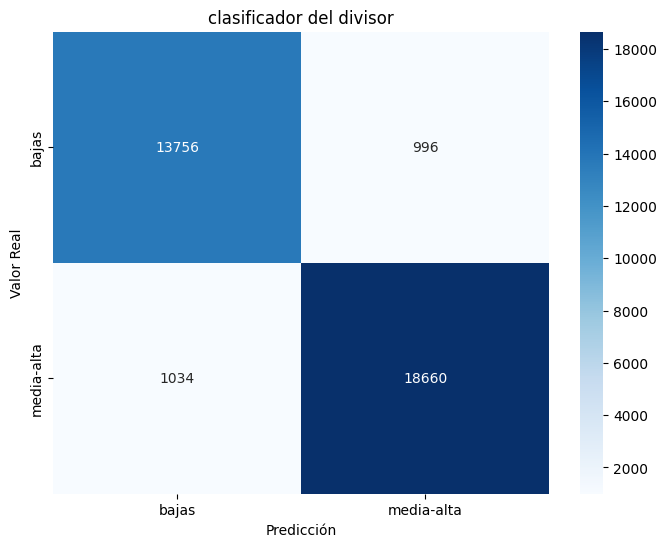

In [13]:
y_divisor = np.where(y_train_reduce <= 1, 0, 1)
y_divisor_test = np.where(y_test_reduce <= 1, 0, 1)
print("Entrenando divisor de clase popular y no popular")
divisor_ = _create_pipeline()
p = {
        'classifier__n_estimators': [100, 300, 500],
        'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split':[2,5,10,20],
        'classifier__min_samples_leaf':[1,2,5,10],
        
}
grid = GridSearchCV(divisor_, p, cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)

grid.fit(X_train_reduce,y_divisor )
div = grid.best_estimator_
predict_div = div.predict(X_test_reduce)
r = classification_report(y_divisor_test, predict_div)
print(r)
cm = confusion_matrix(y_divisor_test, predict_div)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['bajas','media-alta'],
                        yticklabels=['bajas','media-alta'])

plt.ylabel('Valor Real')
plt.title("clasificador del divisor")
plt.xlabel('Predicción')
plt.show()


Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.8s
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.8s
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.8s
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.8s
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.8s
[CV] END classifier__max_depth=None, classifier__min_samples_leaf=1, classifier__min_samples_split=2, classifier__n_estimators=300; total time=   2.3s
[CV] END classifier__max_depth=

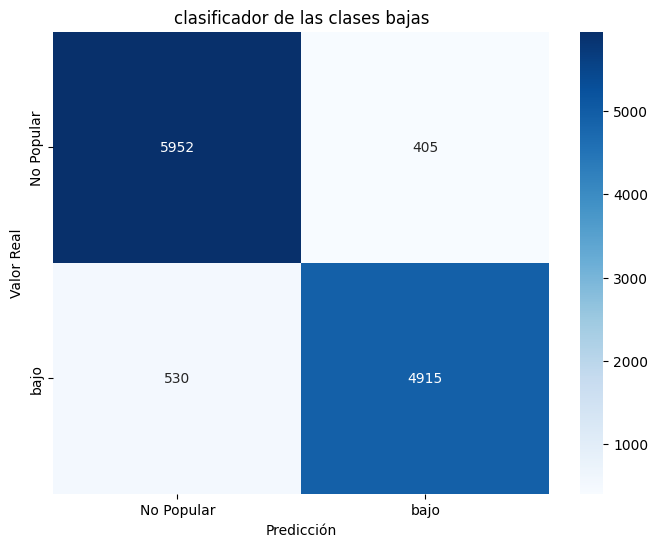

In [14]:
expert_low_ = _create_pipeline()
p = {
        'classifier__n_estimators': [100, 300, 500],
        'classifier__max_depth': [None, 10, 20],
        'classifier__min_samples_split':[2,5,10,20],
        'classifier__min_samples_leaf':[1,2,5,10],

}
grid = GridSearchCV(expert_low_, p, cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)

grid.fit(X_train_low, y_train_low)
model_low = grid.best_estimator_
predict_bajas = model_low.predict(X_test_low)
r = classification_report(y_test_low, predict_bajas)
print(r)
cm = confusion_matrix(y_test_low, predict_bajas)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['No Popular', 'bajo',],
                        yticklabels=['No Popular', 'bajo',])

plt.ylabel('Valor Real')
plt.title("clasificador de las clases bajas")
plt.xlabel('Predicción')
plt.show()

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .........classifier__C=0.1, classifier__gamma=scale; total time= 4.1min
[CV] END .........classifier__C=0.1, classifier__gamma=scale; total time= 4.1min
[CV] END ..........classifier__C=0.1, classifier__gamma=auto; total time= 4.1min
[CV] END .........classifier__C=0.1, classifier__gamma=scale; total time= 4.1min
[CV] END ..........classifier__C=0.1, classifier__gamma=auto; total time= 4.1min
[CV] END .........classifier__C=0.1, classifier__gamma=scale; total time= 4.2min
[CV] END ..........classifier__C=0.1, classifier__gamma=auto; total time= 4.2min
[CV] END .........classifier__C=0.1, classifier__gamma=scale; total time= 4.2min
[CV] END ..........classifier__C=0.1, classifier__gamma=auto; total time= 4.1min
[CV] END ..........classifier__C=0.1, classifier__gamma=auto; total time= 4.1min
[CV] END ...........classifier__C=0.1, classifier__gamma=0.1; total time= 4.2min
[CV] END ..........classifier__C=0.1, classifier

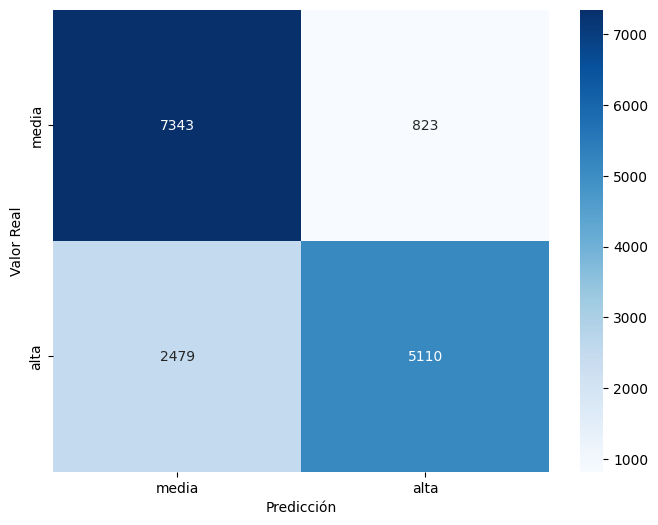

In [20]:
expert_alta = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', SVC(kernel='rbf'))
        ])
p = {
     'classifier__C':[0.1,1,10],
     'classifier__gamma':['scale','auto',0.01,0.1]   

}
grid = GridSearchCV(expert_alta, p, cv=5, scoring='f1_macro', n_jobs=-1,verbose=2)
y_train_alta = y_train_alta
grid.fit(X_train_alta, y_train_alta)
best_model = grid.best_estimator_
predict_alta = best_model.predict(X_test_alta)
r = classification_report(y_test_alta, predict_alta)
print(r)
cm = confusion_matrix(y_test_alta, predict_alta)

print(grid.best_params_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['media', 'alta',],
                        yticklabels=['media', 'alta',])

plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

In [18]:
result = np.zeros(len(X_test_reduce),dtype=int)

mask_low_model= (predict_div==1)
X_ = X_test_reduce[mask_low_model]
r1=best_model.predict(X_)
result[mask_low_model]=r1

mask_alta_model= (predict_div==0)
X__ = X_test_reduce[mask_alta_model]
r2= model_low.predict(X__)
result[mask_alta_model]=r2

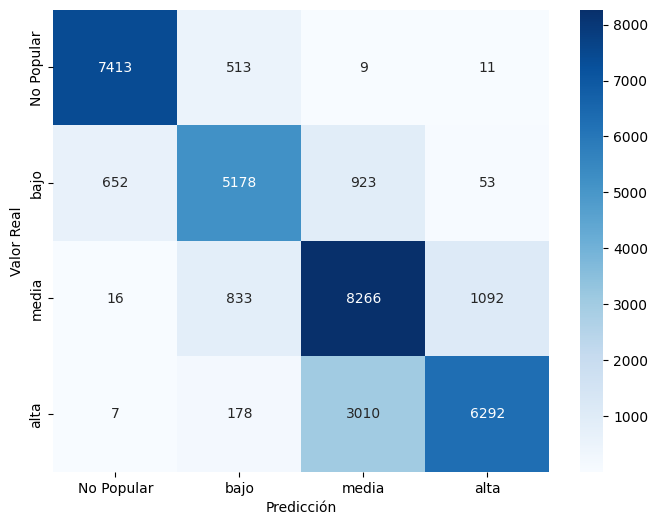

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      7946
           1       0.77      0.76      0.77      6806
           2       0.68      0.81      0.74     10207
           3       0.84      0.66      0.74      9487

    accuracy                           0.79     34446
   macro avg       0.80      0.79      0.79     34446
weighted avg       0.80      0.79      0.79     34446



In [19]:
cm = confusion_matrix(y_test_reduce, result)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Popular', 'bajo','media','alta'],
                yticklabels=['No Popular', 'bajo','media','alta'])
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()
r = classification_report(y_test_reduce, result)
print(r)